# 1. Setup and Initialization
Mengimpor pustaka yang dibutuhkan, mengatur *seed* untuk reproduktibilitas, dan mengonfigurasi perangkat keras (GPU).



## 1.1 Import Libraries & GPU Configuration
Memuat modul TensorFlow/Keras, Pandas, dan Matplotlib. Mengonfigurasi *memory growth* pada GPU untuk optimasi alokasi VRAM selama proses *training*.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Configure random seed for reproducibility across runs
tf.random.set_seed(42)
np.random.seed(42)

# Check GPU availability and configure dynamic memory allocation
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print(f"GPU detected: {physical_devices[0]}")
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("GPU memory growth successfully enabled.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
else:
    print("Warning: No GPU detected. Training will utilize CPU.")

2026-03-17 09:04:56.814675: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 09:04:58.101682: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-17 09:05:01.203317: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU detected: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth successfully enabled.


# 2. Exploratory Data Analysis (EDA)
Menganalisis struktur dataset dan distribusi kelas target untuk skenario klasifikasi *multi-label*.



## 2.1 Load Dataset & Data Formatting
Membaca file `train.csv` dan memodifikasi kolom `image_id`. Penambahan ekstensi `.jpg` diperlukan agar kompatibel dengan metode `flow_from_dataframe` pada Keras.


In [3]:
# Define data paths
csv_path = 'train.csv'
image_dir = 'images/'

# Load the training data into a Pandas DataFrame
df = pd.read_csv(csv_path)

# Append '.jpg' to image_id column for flow_from_dataframe compatibility
df['image_id'] = df['image_id'].apply(lambda x: f"{x}.jpg")

# Display the first 5 rows to verify the transformation
print("Dataset Head:")
display(df.head())

Dataset Head:


,image_id,healthy,multiple_diseases,rust,scab
0,Train_0.jpg,0,0,0,1
1,Train_1.jpg,0,1,0,0
2,Train_2.jpg,1,0,0,0
3,Train_3.jpg,0,0,1,0
4,Train_4.jpg,1,0,0,0



## 2.2 Class Distribution Visualization
Memvisualisasikan jumlah sampel untuk masing-masing kelas guna mengidentifikasi potensi *class imbalance* pada dataset.

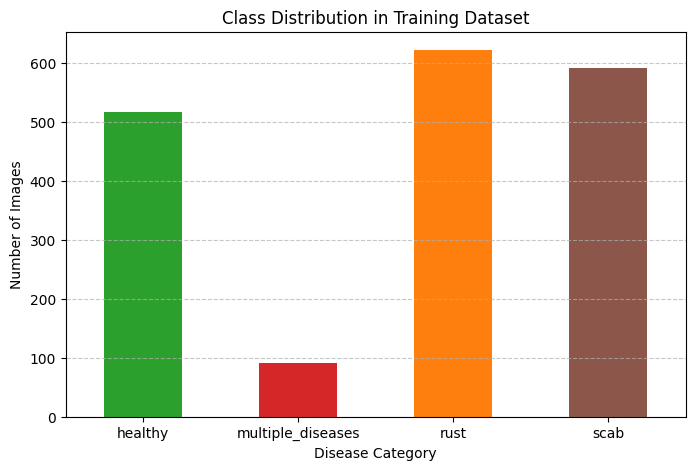

In [4]:
# Define the target classes based on the dataset columns
target_classes = ['healthy', 'multiple_diseases', 'rust', 'scab']

# Calculate the total count of positive samples for each class
class_counts = df[target_classes].sum()

# Plot the class distribution
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['#2ca02c', '#d62728', '#ff7f0e', '#8c564b'])
plt.title('Class Distribution in Training Dataset')
plt.ylabel('Number of Images')
plt.xlabel('Disease Category')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Data Splitting
Memisahkan dataset menjadi himpunan pelatihan (*training set*) dan validasi (*validation set*) untuk mengevaluasi generalisasi model secara objektif.

## 3.1 Train-Validation Split
Menggunakan `train_test_split` dengan proporsi 80:20. Pengaturan *random state* memastikan pemisahan data tetap konsisten pada setiap iterasi eksekusi.

In [5]:
from sklearn.model_selection import train_test_split

# Split the dataframe into 80% training and 20% validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Verify the shape of the resulting dataframes
print(f"Training set configuration: {train_df.shape[0]} samples")
print(f"Validation set configuration: {val_df.shape[0]} samples")

Training set configuration: 1456 samples
Validation set configuration: 365 samples


# 4. Data Preprocessing and Augmentation
Menerapkan teknik augmentasi data untuk mengurangi *overfitting* dan meningkatkan ketahanan (*robustness*) model terhadap variasi pencahayaan, rotasi, dan latar belakang (*domain shift*).

## 4.1 Initialize ImageDataGenerator
Mengonfigurasi parameter augmentasi spasial dan intensitas piksel untuk himpunan data latih. Pada tahap ini, kita secara khusus menggunakan `preprocess_input` bawaan arsitektur EfficientNet untuk normalisasi nilai piksel (sesuai standar *pre-trained* ImageNet), menggantikan metode *rescaling* standar `1./255`.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# Define spatial and pixel-level augmentation strategies for training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Validation data must only be normalized using the same preprocess_input function
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

## 4.2 Configure DataFrame Iterators
Menggunakan fungsi `flow_from_dataframe` untuk memuat citra secara dinamis (*lazy loading*) langsung dari direktori berdasarkan referensi *file path* pada *dataframe*. Resolusi target (dimensi input) diatur pada ukuran optimal untuk arsitektur EfficientNetB3 yakni 300x300 piksel. Parameter `class_mode='raw'` diwajibkan karena target output prediksi berupa representasi metrik *multi-label*.

In [7]:
# Hyperparameters for data loading
BATCH_SIZE = 32
TARGET_SIZE = (300, 300)

# Instantiate the training data iterator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='image_id',
    y_col=target_classes,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True,
    seed=42
)

# Instantiate the validation data iterator
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='image_id',
    y_col=target_classes,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

Found 1456 validated image filenames.
Found 365 validated image filenames.


# 5. Model Architecture
Membangun arsitektur *Deep Learning* menggunakan *pre-trained model* EfficientNetB3 yang disesuaikan untuk tugas klasifikasi *multi-label*.

## 5.1 Load Pre-trained Base Model
Menginisialisasi arsitektur EfficientNetB3 tanpa *classification head* bawaan (`include_top=False`) dan memuat bobot pra-latih dari ImageNet.?

In [8]:
from tensorflow.keras.applications import EfficientNetB3

# Define input shape corresponding to the ImageDataGenerator target size
INPUT_SHAPE = (300, 300, 3)

# Load the base model with pre-trained ImageNet weights
base_model = EfficientNetB3(
    weights='imagenet', 
    include_top=False, 
    input_shape=INPUT_SHAPE
)

# Freeze the base model layers initially to prevent weight destruction during initial training
base_model.trainable = False

I0000 00:00:1773713398.691741    1491 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 5.2 Build Custom Classification Head
Menambahkan *Global Average Pooling*, lapisan regulariasi (*Dropout*), dan lapisan *Dense* dengan fungsi aktivasi `sigmoid` untuk menghasilkan output probabilitas independen pada 4 kelas.

In [9]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
import numpy as np

# Prior probability untuk handle imbalance
priors = np.array([416/1456, 73/1456, 502/1456, 465/1456])
bias_init = tf.keras.initializers.Constant(np.log(priors / (1 - priors)))

x = base_model.output
x = GlobalAveragePooling2D(name='global_average_pooling')(x)
x = Dropout(0.4, name='dropout_regularization')(x)

predictions = Dense(4, activation='sigmoid', name='classifier_output', bias_initializer=bias_init)(x)

model = Model(inputs=base_model.input, outputs=predictions)
print("Custom EfficientNetB3 Architecture Summary:")
model.summary()

Custom EfficientNetB3 Architecture Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 10,789,683 (41.16 MB)

 Trainable params: 6,148 (24.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

# 6. Model Compilation
Mengonfigurasi algoritma optimasi, fungsi kerugian (*loss function*), dan metrik evaluasi untuk proses *training*.

## 6.1 Compile the Multi-label Model
Menggunakan `binary_crossentropy` karena setiap kelas diprediksi secara independen. Metrik performa difokuskan pada `AUC` (Area Under the ROC Curve) yang merupakan standar evaluasi pada *imbalanced dataset*.

In [10]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, BinaryAccuracy

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc', multi_label=True)]
)

print("Model successfully compiled for Multi-label!")

Model successfully compiled for Multi-label!


# 7. Callbacks Configuration
Menyiapkan mekanisme kontrol otomatis selama proses *training* untuk mencegah *overfitting* dan menyimpan model dengan performa terbaik.

## 7.1 Setup Checkpoint, Early Stopping, and Learning Rate Scheduler
- **ModelCheckpoint:** Menyimpan bobot (`.keras`) hanya pada *epoch* dengan performa `val_auc` tertinggi.
- **EarlyStopping:** Menghentikan iterasi secara prematur jika metrik tidak menunjukkan perbaikan setelah beberapa *epoch* (Patience).
- **ReduceLROnPlateau:** Menurunkan *Learning Rate* secara adaptif jika *loss* tertahan di area minimum lokal (*local minima*).

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Create directory to store the best model
if not os.path.exists('models'):
    os.makedirs('models')

MODEL_SAVE_PATH = 'models/efficientnetb3_multilabel_best.keras'

# 1. Save the best model based on Validation AUC
checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

# 2. Stop training if Validation AUC doesn't improve for 8 epochs
early_stopping = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# 3. Reduce Learning Rate if Validation Loss stagnates for 3 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Bundle the callbacks
callbacks_list = [checkpoint, early_stopping, reduce_lr]

# 8. Model Training Execution
Memulai proses iterasi *training* dengan memanfaatkan GPU *acceleration*.

## 8.1 Execute Training Phase
Menjalankan metode `fit` dengan menetapkan *steps per epoch* berdasarkan ukuran *batch*. Fase pertama ini ditujukan untuk melatih *Custom Classification Head* (Transfer Learning: Feature Extraction).

In [ ]:
# Define maximum epochs for the initial training phase
EPOCHS = 20

print("Initiating Phase 1 Training (Feature Extraction)...")

# Execute training loop
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=callbacks_list,
    verbose=1
)

print(f"Training completed. Best model saved to: {MODEL_SAVE_PATH}")

Initiating Phase 1 Training (Feature Extraction)...
Epoch 1/20


2026-03-17 09:17:25.760371: I external/local_xla/xla/service/service.cc:163] XLA service 0x71171c014620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-17 09:17:25.760441: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-03-17 09:17:26.324643: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-17 09:17:29.823362: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-17 09:17:35.241579: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 894.93MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-17 09:17:37.125

20/45 ━━━━━━━━━━━━━━━━━━━━ 20s 821ms/step - accuracy: 0.3585 - auc: 0.5393 - loss: 0.5252

2026-03-17 09:18:36.767368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:18:37.021932: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:18:37.413437: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:18:37.452682: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[16,816,19,19]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,816,19,19]{3,2,1,0}, f32[816,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feat

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4214 - auc: 0.5824 - loss: 0.5055
Epoch 1: val_auc improved from None to 0.87612, saving model to models/efficientnetb3_multilabel_best.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5147 - auc: 0.6518 - loss: 0.4788 - val_accuracy: 0.7188 - val_auc: 0.8761 - val_loss: 0.3943 - learning_rate: 0.0010
Epoch 2/20
 1/45 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.6250 - auc: 0.7474 - loss: 0.4173

/home/alvaro/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_auc improved from 0.87612 to 0.87873, saving model to models/efficientnetb3_multilabel_best.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.6250 - auc: 0.7474 - loss: 0.4173 - val_accuracy: 0.7159 - val_auc: 0.8787 - val_loss: 0.3924 - learning_rate: 0.0010
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.6631 - auc: 0.7850 - loss: 0.4113
Epoch 3: val_auc improved from 0.87873 to 0.91319, saving model to models/efficientnetb3_multilabel_best.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 42s 918ms/step - accuracy: 0.6889 - auc: 0.7940 - loss: 0.3917 - val_accuracy: 0.7415 - val_auc: 0.9132 - val_loss: 0.3416 - learning_rate: 0.0010
Epoch 4/20
 1/45 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - accuracy: 0.5625 - auc: 0.8220 - loss: 0.4298
Epoch 4: val_auc improved from 0.91319 to 0.91416, saving model to models/efficientnetb3_multilabel_best.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.5625 - auc: 0.8220 - loss: 0.4298 - val_accuracy: 0.7415 - val_a

# 9. Model Fine-Tuning (Phase 2)
Membuka kunci arsitektur *base model* untuk melatih ulang seluruh parameter jaringan. Tahap ini memungkinkan model mengekstraksi fitur visual spesifik (domain-specific features) dari dataset *Plant Pathology*.

## 9.1 Unfreeze Base Model & Recompile
Mengubah status `trainable` pada *base model* menjadi `True`. Re-kompilasi wajib dilakukan dengan *Learning Rate* yang jauh lebih kecil (contoh: `1e-5`) untuk mencegah fenomena *Catastrophic Forgetting* (kerusakan bobot pra-latih secara masif).

In [13]:
# 1. Unfreeze base model (Buka semua kunci layer)
base_model.trainable = True

print(f"Number of trainable variables after unfreezing: {len(model.trainable_weights)}")

# 2. Recompile dengan aturan Multi-label yang bener
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # LR sangat kecil biar gak ngerusak bobot asli
    loss='binary_crossentropy', # Ganti dari categorical ke binary
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)] # Tambahin multi_label=True
)

# 3. Build optimizer supaya variable terinisialisasi (Biar gak kaget GPU-nya)
import numpy as np
dummy = np.zeros((1, 300, 300, 3))
model.predict(dummy, verbose=0)

print("Model successfully re-compiled for Fine-Tuning (Multi-label mode)!")

Number of trainable variables after unfreezing: 340


2026-03-17 09:34:50.083021: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:34:50.316803: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:34:50.540844: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:34:51.466571: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:34:51.751352: E external/local_xla/xla/stream_

Model successfully re-compiled for Fine-Tuning (Multi-label mode)!


## 9.2 Fine-Tuning Execution
Menyiapkan *generators* dengan ukuran *batch* yang lebih kecil untuk mengakomodasi beban memori GPU selama fase *fine-tuning*. Pada tahap ini, seluruh parameter model diperbarui dengan *Learning Rate* yang sangat rendah. Metrik utama tetap difokuskan pada perbaikan nilai `val_auc`.

In [14]:
import os

# Matikan XLA JIT untuk sementara guna menghindari hang pada GPU seri RTX 30
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

# 1. Reinitialize generators dengan batch size kecil (Crucial untuk VRAM 4GB)
# Batch size diturunkan ke 8 karena seluruh parameter (10jt+) sekarang berstatus Trainable
train_generator_ft = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='image_id',
    y_col=target_classes,
    target_size=TARGET_SIZE,
    batch_size=8,
    class_mode='raw',
    shuffle=True,
    seed=42
)

val_generator_ft = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='image_id',
    y_col=target_classes,
    target_size=TARGET_SIZE,
    batch_size=8,
    class_mode='raw',
    shuffle=False
)

# 2. Define Callbacks khusus untuk Fine-Tuning
FINE_TUNE_EPOCHS = 30
FINETUNE_MODEL_PATH = 'models/efficientnetb3_multilabel_finetuned_best.keras'

checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    filepath=FINETUNE_MODEL_PATH,
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ft = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.2,
    patience=3,
    min_lr=1e-8, # 🔥 Sudah diturunkan agar lebih sensitif
    verbose=1
)

callbacks_ft = [checkpoint_ft, early_stopping_ft, reduce_lr_ft]

print("Initiating Phase 2 Training (Fine-Tuning)...")

# 3. Execute Fine-Tuning
history_ft = model.fit(
    train_generator_ft,
    validation_data=val_generator_ft,
    epochs=FINE_TUNE_EPOCHS,
    steps_per_epoch=train_generator_ft.samples // train_generator_ft.batch_size,
    validation_steps=val_generator_ft.samples // val_generator_ft.batch_size,
    callbacks=callbacks_ft,
    verbose=1
)

print(f"Fine-Tuning completed. Ultimate best model saved to: {FINETUNE_MODEL_PATH}")

Found 1456 validated image filenames.
Found 365 validated image filenames.
Initiating Phase 2 Training (Fine-Tuning)...
Epoch 1/30


2026-03-17 09:39:35.322745: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:39:35.560080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:39:36.608161: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:39:36.880967: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-17 09:39:37.177344: E external/local_xla/xla/stream_

182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6262 - auc: 0.7710 - loss: 0.4031
Epoch 1: val_auc improved from None to 0.92766, saving model to models/efficientnetb3_multilabel_finetuned_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 204s 328ms/step - accuracy: 0.6772 - auc: 0.8032 - loss: 0.3794 - val_accuracy: 0.8056 - val_auc: 0.9277 - val_loss: 0.2575 - learning_rate: 1.0000e-05
Epoch 2/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.7762 - auc: 0.8607 - loss: 0.3139
Epoch 2: val_auc did not improve from 0.92766
182/182 ━━━━━━━━━━━━━━━━━━━━ 42s 225ms/step - accuracy: 0.7940 - auc: 0.8670 - loss: 0.2959 - val_accuracy: 0.8750 - val_auc: 0.9268 - val_loss: 0.2060 - learning_rate: 1.0000e-05
Epoch 3/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.8106 - auc: 0.8833 - loss: 0.2553
Epoch 3: val_auc improved from 0.92766 to 0.93338, saving model to models/efficientnetb3_multilabel_finetuned_best.keras
182/182 ━━━━━━━━━━━━━━━━━━━━ 45s 248ms/step - accuracy: 0.8

# 10. Model Inference & Validation
Memuat kembali (*load*) bobot model terbaik yang telah disimpan oleh `ModelCheckpoint` untuk melakukan prediksi pada data citra baru (*unseen data*).

## 10.1 Load Saved Model & Predict
Menggunakan fungsi `load_model` dan mendefinisikan *pipeline preprocessing* (resizing, normalization) yang identik dengan fase *training* sebelum citra diumpankan ke model.

In [15]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import os

# Gunakan path model Fine-Tuning yang terakhir kita simpan
SAVED_MODEL_PATH = 'models/efficientnetb3_multilabel_finetuned_best.keras'

print("Memuat model dewa dari harddisk... Mohon tunggu.")
if os.path.exists(SAVED_MODEL_PATH):
    model_dewa = tf.keras.models.load_model(SAVED_MODEL_PATH)
    print(f"✅ Model sukses dimuat dari: {SAVED_MODEL_PATH}")
else:
    print("❌ ERROR: Model tidak ditemukan. Pastikan path-nya benar.")

def prediksi_daun_liar(image_path):
    if not os.path.exists(image_path):
        print(f"❌ File {image_path} gak ada Dul!")
        return

    print(f"\nMenganalisis citra: {image_path}")
    
    # 1. Load & Resize
    img = image.load_img(image_path, target_size=(300, 300))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # 🔥 FIX UTAMA: Pake preprocess_input, JANGAN dibagi 255 manual
    img_array = preprocess_input(img_array)
    
    # 2. Predict
    prediksi = model_dewa.predict(img_array, verbose=0)[0]
    kategori = ['Healthy', 'Multiple Diseases', 'Rust', 'Scab']
    
    print("-" * 35)
    print(f"{'PENYAKIT':<20} | {'PROBABILITAS':<10}")
    print("-" * 35)
    
    for i, cat in enumerate(kategori):
        prob = prediksi[i]
        bar = "█" * int(prob * 20)
        status = "⭐" if prob > 0.5 else "  "
        print(f"{status} {cat:<18} | {prob*100:>6.2f}% {bar}")
    print("-" * 35)

# Tes pake gambar sakti lu
prediksi_daun_liar('4.jpg')

Memuat model dewa dari harddisk... Mohon tunggu.
✅ Model sukses dimuat dari: models/efficientnetb3_multilabel_finetuned_best.keras

Menganalisis citra: 4.jpg
-----------------------------------
PENYAKIT             | PROBABILITAS
-----------------------------------
   Healthy            |   3.52% 
   Multiple Diseases  |   7.62% █
   Rust               |   0.69% 
⭐ Scab               |  92.44% ██████████████████
-----------------------------------


# 11. Model Performance Evaluation
Tahap evaluasi komprehensif untuk mengukur sejauh mana model dewa mampu menggeneralisasi data yang belum pernah dilihat sebelumnya (*unseen data*).

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

## 11.1 Model Inference & Validation
Memuat kembali bobot model terbaik dari penyimpanan lokal dan melakukan inferensi pada seluruh himpunan data validasi untuk mendapatkan nilai probabilitas prediksi.

In [3]:
# 1. Menyiapkan kembali data validasi
df = pd.read_csv('train.csv')
df['image_id'] = df['image_id'].apply(lambda x: f"{x}.jpg")
target_classes = ['healthy', 'multiple_diseases', 'rust', 'scab']
_, val_df = train_test_split(df, test_size=0.2, random_state=42)

# 2. Menyiapkan generator validasi
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
eval_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory='images/',
    x_col='image_id',
    y_col=target_classes,
    target_size=(300, 300),
    batch_size=8,
    class_mode='raw',
    shuffle=False
)

# 3. Memuat model terbaik
SAVED_MODEL_PATH = 'models/efficientnetb3_multilabel_finetuned_best.keras'
print("Memuat model...")
model = tf.keras.models.load_model(SAVED_MODEL_PATH)

# 4. Melakukan prediksi
print("Melakukan prediksi pada set validasi...")
y_pred = model.predict(eval_generator, verbose=1)
y_true = val_df[target_classes].values
y_pred_bool = (y_pred > 0.5).astype(int)

print("Prediksi selesai.")

Found 365 validated image filenames.
Memuat model...
Melakukan prediksi pada set validasi...
46/46 ━━━━━━━━━━━━━━━━━━━━ 22s 285ms/step
Prediksi selesai.


## 11.2 Classification Report and Confusion Matrix
Menganalisis performa klasifikasi per kelas menggunakan *Precision, Recall,* dan *F1-Score*, serta memvisualisasikan matriks kebingungan (Confusion Matrix) untuk melihat distribusi ketepatan prediksi model.

=== CLASSIFICATION REPORT ===

                   precision    recall  f1-score   support

          healthy       0.95      0.98      0.97       100
multiple_diseases       0.91      0.56      0.69        18
             rust       0.98      0.98      0.98       120
             scab       0.97      0.95      0.96       127

        micro avg       0.96      0.95      0.96       365
        macro avg       0.95      0.87      0.90       365
     weighted avg       0.96      0.95      0.95       365
      samples avg       0.95      0.95      0.95       365



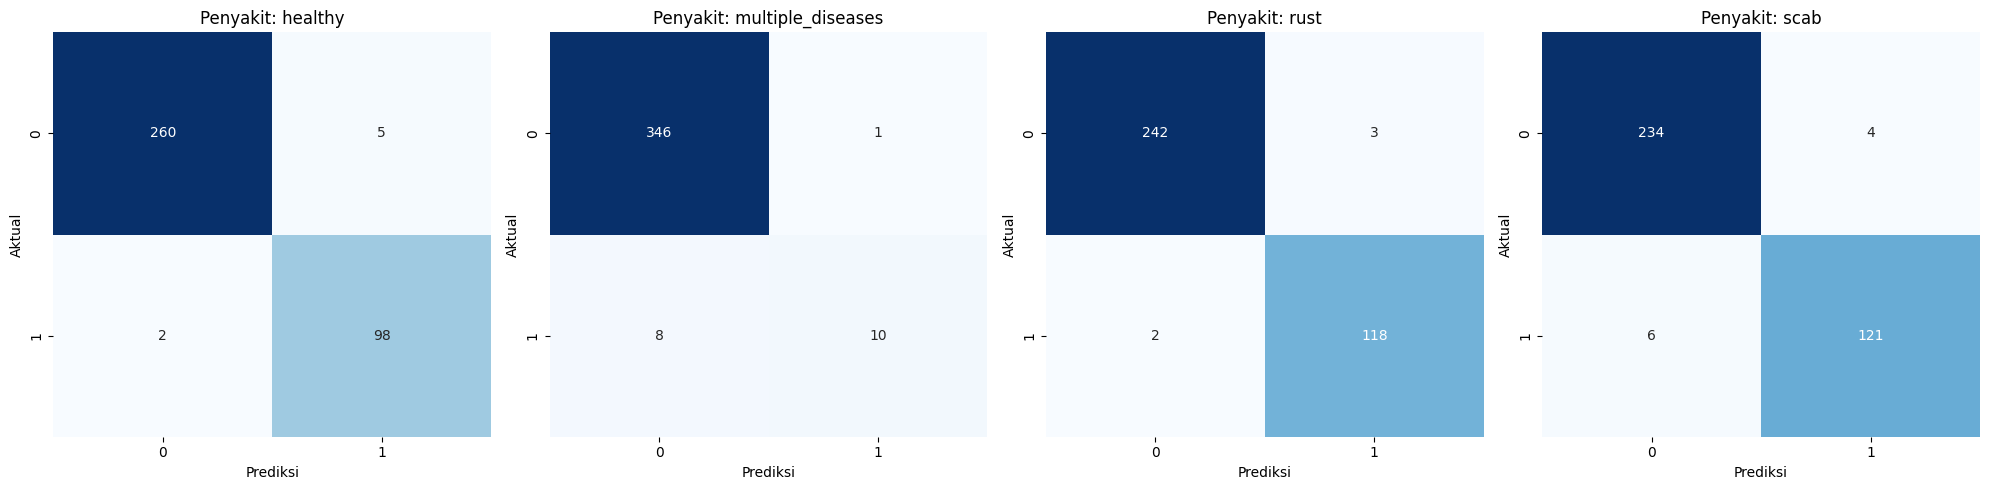

In [4]:
# Classification Report
print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_true, y_pred_bool, target_names=target_classes, zero_division=0))

# Confusion Matrix untuk setiap kelas
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, class_name in enumerate(target_classes):
    cm = confusion_matrix(y_true[:, i], y_pred_bool[:, i])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'Penyakit: {class_name}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')
plt.tight_layout()
plt.show()

## 11.3 ROC AUC Curve Analysis
Memvisualisasikan kemampuan model dalam memisahkan antar kelas melalui kurva Receiver Operating Characteristic (ROC). Nilai AUC yang mendekati 1.0 menunjukkan performa diskriminasi yang superior.

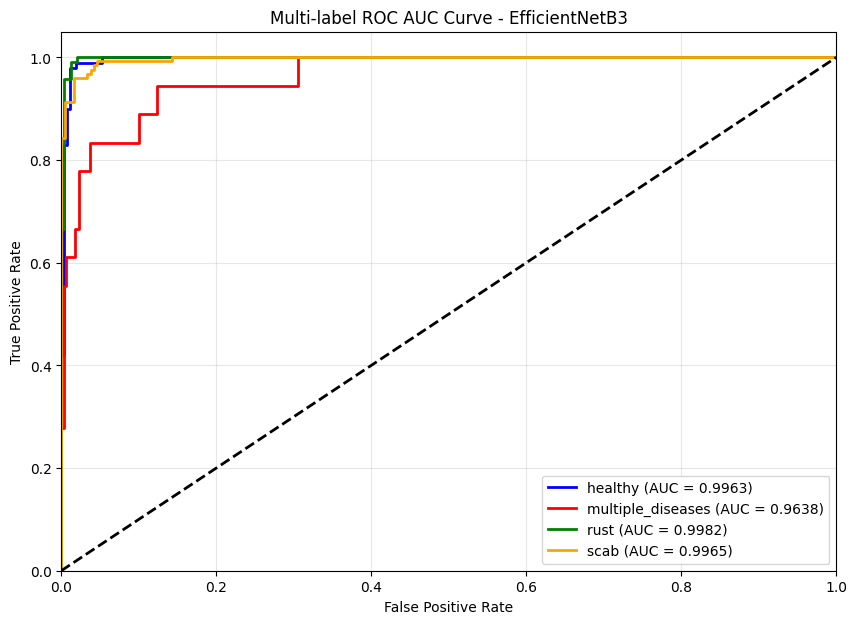

In [ ]:
# ROC AUC Curve untuk setiap kelas
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange']

for i, class_name in enumerate(target_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-label ROC AUC Curve - EfficientNetB3')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()